In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.DataFrame({
    'area':[6.7, 4.6, 3.5, 5.5],
    'price':[9.1, 5.9, 4.6, 6.7]
})
df

,area,price
0,6.7,9.1
1,4.6,5.9
2,3.5,4.6
3,5.5,6.7


# LinearRegression Stochastic

In [23]:
class LinearRegresionPickOneSample:
    def __init__(self,lr = 0.01,Epoch = 100,batch_size = 1,shuffle = False):
        self.lr = lr
        self.w = None
        self.Epoch = Epoch
        self.batch_size = batch_size
        self.shuffle = shuffle
    def checkDim(self,X):
        if X.ndim == 1:
            raise ValueError('X must be 2 dimentional')
        else: return 1
    # add feature = 1 in head each sample
    def addFeature1(self,X):
        if X.shape[1] == self.Nfeature + 1: return X
        feature1 = np.ones(X.shape[0]).reshape(-1,1)
        return np.concatenate((feature1,X),axis = 1)
    # function predcit
    def predict(self,X):
        if self.checkDim(X):
            X = self.addFeature1(X)
        return X@self.w.T
    # function compute loss
    def compute_Loss(self,y_pred,y):
        return(y_pred-y)**2
    # function compute gradient loss_w
    def dL_dw(self,y_pred,y,X):
        return 2*X*(y_pred-y)
    # function fit model
    def fit(self,X,y):
        if self.checkDim(X):
            self.Nsample, self.Nfeature = X.shape
            X = self.addFeature1(X)
            # random weight of model
            self.w = np.random.uniform(-1,1,size=self.Nfeature+1).reshape(1,self.Nfeature+1)
            # list loss of N epoch
            self.Losses = [ ] 
            data_train = np.concatenate((X,y.reshape(self.Nsample,-1)),axis = 1)
            for epoch in range(self.Epoch):
                Loss = []  # loss of each epoch
                if self.shuffle: np.random.shuffle(data_train)
                for i in range(0,self.Nsample,self.batch_size):
                    batch = data_train[i:i+self.batch_size]
                    X_train, y_train = batch[:,:-1],batch[:,-1]
                    y_pred = self.predict(X_train)
                    loss = self.compute_Loss(y_pred,y_train)
                    Loss.append(loss)
                    dL_dw = self.dL_dw(y_pred,y_train,X_train)
                    self.w -= self.lr*dL_dw
                self.Losses.append(sum(Loss)/len(Loss))
                print(f"epoch:{epoch+1:<5} ======= Loss = {self.Losses[-1].item():<10.4f} =============== w = {str(self.w)}")

In [24]:
rg = LinearRegresionPickOneSample()

In [25]:
X = df.iloc[:,:-1].to_numpy()
y = df.iloc[:,-1].to_numpy()
y

array([9.1, 5.9, 4.6, 6.7])

In [26]:
rg.fit(X,y)

epoch:1     ======= Loss = 52.5674    =============== w = [[0.24618192 1.18242501]]
epoch:2     ======= Loss = 0.3210     =============== w = [[0.24481442 1.20850352]]
epoch:3     ======= Loss = 0.2509     =============== w = [[0.23965727 1.20981948]]
epoch:4     ======= Loss = 0.2494     =============== w = [[0.23447633 1.21081694]]
epoch:5     ======= Loss = 0.2486     =============== w = [[0.22931922 1.21180572]]
epoch:6     ======= Loss = 0.2479     =============== w = [[0.22418642 1.2127898 ]]
epoch:7     ======= Loss = 0.2471     =============== w = [[0.21907783 1.21376923]]
epoch:8     ======= Loss = 0.2464     =============== w = [[0.21399334 1.21474404]]
epoch:9     ======= Loss = 0.2456     =============== w = [[0.20893284 1.21571426]]
epoch:10    ======= Loss = 0.2449     =============== w = [[0.2038962 1.2166799]]
epoch:11    ======= Loss = 0.2442     =============== w = [[0.19888331 1.21764098]]
epoch:12    ======= Loss = 0.2435     =============== w = [[0.19389407 1.21859

# Vẽ biểu đồ thể hiện mô hình sau khi đã huấn luyện

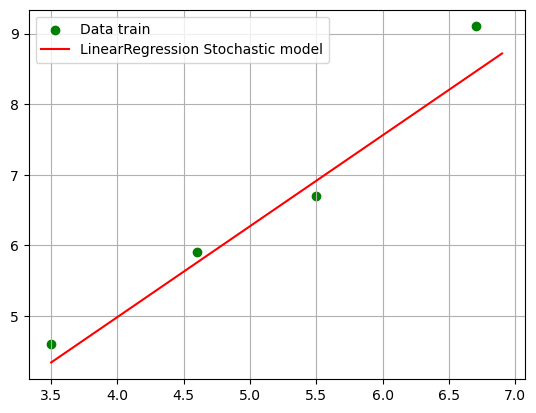

In [35]:
plt.scatter(X,y,c='g',label ='Data train')
x_plt = np.arange(3.5,7,0.1)
y_plot = rg.w[0,1]*x_plt + rg.w[0,0]
plt.plot(x_plt,y_plot,'r',label ='LinearRegression Stochastic model')
plt.legend()
plt.grid()
plt.show()